In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/datasets/mymoviedb.csv', sep=',', engine='python')
display(df.head())

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
# I am now performing basic eda how can we take information about any dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [5]:
df.shape

(9837, 9)

In [6]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [7]:
df.isnull().sum()

,0
Release_Date,0
Title,9
Overview,9
Popularity,10
Vote_Count,10
Vote_Average,10
Original_Language,10
Genre,11
Poster_Url,11


In [8]:
(df.isnull().sum() / len(df)) * 100

,0
Release_Date,0.000000
Title,0.091491
Overview,0.091491
Popularity,0.101657
Vote_Count,0.101657
Vote_Average,0.101657
Original_Language,0.101657
Genre,0.111823
Poster_Url,0.111823


Some dates are not valid dates they are anything so we have to pass a parameter errors='coerce' within pd.to_datetime. this will concert any invalid date entries to NaT(not a time) without stopping the process. that format='mixed' to help pandas handle different date formats that might be present.

In [9]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce', format='mixed')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9828 non-null   object        
 2   Overview           9828 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9827 non-null   object        
 5   Vote_Average       9827 non-null   object        
 6   Original_Language  9827 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 691.8+ KB


Before filling null values, it's good practice to ensure numerical columns are of a numeric data type. 'Vote_Count' and 'Vote_Average' are currently `object` type, which might indicate mixed data or non-numeric entries. Let's convert them to numeric, coercing errors, and then fill nulls appropriately.

In [10]:
# Convert 'Vote_Count' and 'Vote_Average' to numeric, coercing errors
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# Fill null values for numerical columns with their median
numerical_cols = ['Popularity', 'Vote_Count', 'Vote_Average']
for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill null values for object (string) columns with 'Unknown'
object_cols = ['Title', 'Overview', 'Original_Language', 'Genre', 'Poster_Url']
for col in object_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill null values for 'Release_Date' (datetime) with the mode
# The mode is appropriate for categorical or date/time features where a single most frequent value makes sense.
if 'Release_Date' in df.columns:
    df['Release_Date'] = df['Release_Date'].fillna(df['Release_Date'].mode()[0])

# Display the count of null values after filling to verify
display(df.isnull().sum())

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


In [11]:
print(df.info(),'\n')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9837 non-null   datetime64[ns]
 1   Title              9837 non-null   object        
 2   Overview           9837 non-null   object        
 3   Popularity         9837 non-null   float64       
 4   Vote_Count         9837 non-null   float64       
 5   Vote_Average       9837 non-null   float64       
 6   Original_Language  9837 non-null   object        
 7   Genre              9837 non-null   object        
 8   Poster_Url         9837 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 691.8+ KB
None 

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dt

In [12]:
df.head(1)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...


# now we can ask  some good questions and try to answer them this is very important skill in eda

In [13]:
# which language appears most?
df['Original_Language'].value_counts().head(10)

,count
Original_Language,
en,7569
ja,645
es,339
fr,292
ko,170
zh,129
it,123
cn,109
ru,83


In [14]:
# which genres are very common>
df['Genre'].value_counts().head(10)

,count
Genre,
Drama,466
Comedy,403
"Drama, Romance",248
Horror,238
"Horror, Thriller",199
"Comedy, Romance",196
Documentary,139
"Comedy, Drama",137
"Action, Thriller",125


In [15]:
# what are the most popular 25 movies in this dataset ?
df[['Title', 'Popularity']].sort_values(by="Popularity", ascending=False).head(25)

,Title,Popularity
0,Spider-Man: No Way Home,5083.954
1,The Batman,3827.658
2,No Exit,2618.087
3,Encanto,2402.201
4,The King's Man,1895.511
5,The Commando,1750.484
6,Scream,1675.161
7,Kimi,1601.782
8,Fistful of Vengeance,1594.013
9,Eternals,1537.406


In [16]:
# top 25 highest rated movies ?
df[['Title','Vote_Average']].sort_values(by='Vote_Average', ascending=False).head(25)

,Title,Vote_Average
9401,Kung Fu Master Huo Yuanjia,10.0
7349,Franco Escamilla: Por La Anécdota,9.2
2335,Impossible Things,9.1
667,Demon Slayer: Kimetsu no Yaiba Sibling's Bond,9.1
7411,My Sex Doll,9.0
6738,Mission «Sky»,9.0
7024,Sex School: Dorms of Desire,9.0
2401,The Three Deaths of Marisela Escobedo,9.0
5079,"Ni tuyo, Ni mía",8.9
7049,Bring the Soul: The Movie,8.9


# What is univariate analysis and how can we do it on categorical dataset and numerical ?
We will find out these things below.

# 1. Categorical Data

- a) Count Plot

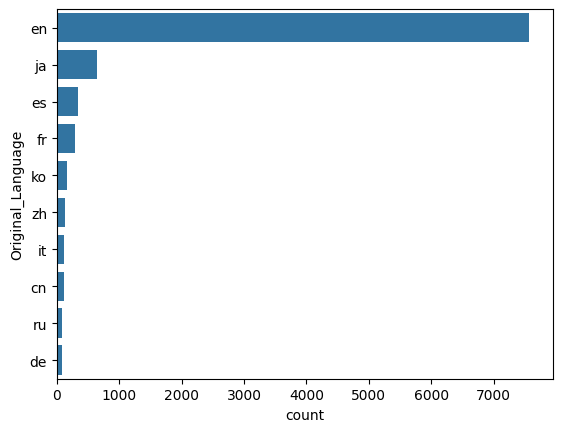

In [26]:
# because there are two much languages i am using only top 10 language frequencies then plot them into that data
top_lang = df['Original_Language'].value_counts().head(10)

sns.countplot(
    y='Original_Language',
    data=df,
    order=top_lang.index
)

plt.show()

- b) pie chart

<Axes: ylabel='count'>

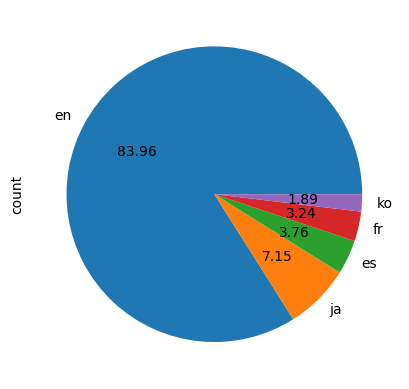

In [31]:
# We can also use pie chart here
df['Original_Language'].value_counts().head(5).plot(kind='pie', autopct='%.2f')


# 2. Numerical Type

a) Histogram

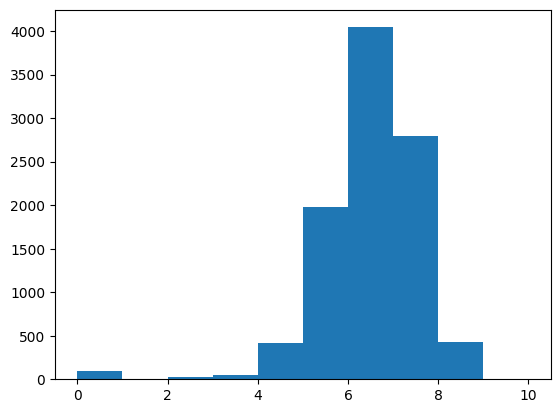

In [40]:
plt.hist(df['Vote_Average'])
plt.show()

In [37]:
df.head(5)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122.0,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076.0,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793.0,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


2) Distplot

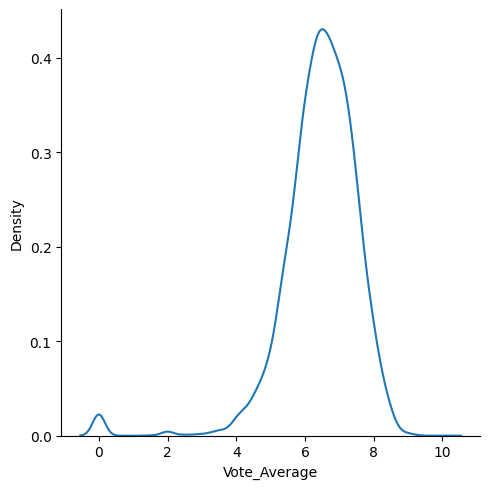

In [44]:
sns.displot(df['Vote_Average'], kind='kde')

3) BoxPlot

<Axes: ylabel='Vote_Average'>

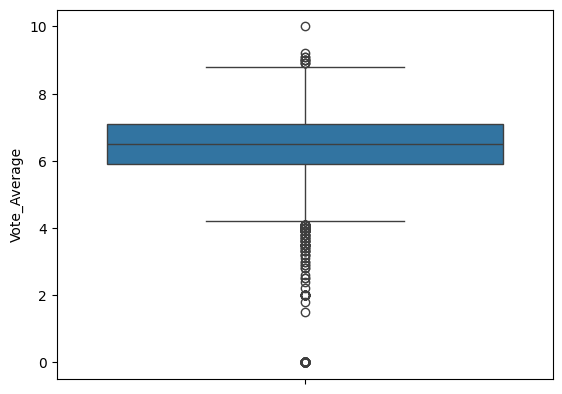

In [45]:
sns.boxplot(df['Vote_Average'])

### 4) Violin Plot

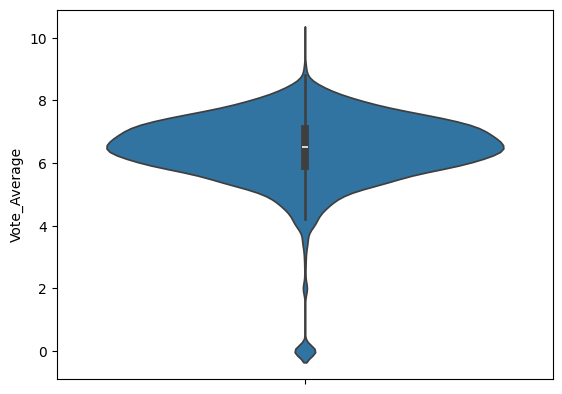

In [46]:
sns.violinplot(df['Vote_Average'])
plt.show()